# Model Trainig

Import Data and Required Pacekages and train Model

In [2]:
## import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## import model required libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
# from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB,BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

## import evaluation metrics
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
#--- IGNORE --- WARNING:
import warnings
warnings.filterwarnings('ignore')

In [76]:
## load dataset
df= pd.read_csv("data\Data.csv")

In [53]:
# dataset first 5 rows
df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [77]:
## signup_time	purchase_time columns have object data type, we need to convert them to datetime data type
df['signup_time'] = pd.to_datetime(df['signup_time'])
df['purchase_time'] = pd.to_datetime(df['purchase_time'])

In [78]:
## feature engineering: signup and purhase time convert into datetime format and sparate date,day,time
df['signup_year'] = df['signup_time'].dt.year
df['signup_month'] = df['signup_time'].dt.month
df['signup_day'] = df['signup_time'].dt.day
df['signup_hour'] = df['signup_time'].dt.hour
df['signup_dayofweek'] = df['signup_time'].dt.dayofweek

df['purchase_year'] = df['purchase_time'].dt.year
df['purchase_month'] = df['purchase_time'].dt.month
df['purchase_day'] = df['purchase_time'].dt.day
df['purchase_hour'] = df['purchase_time'].dt.hour
df['purchase_dayofweek'] = df['purchase_time'].dt.dayofweek

In [79]:
## drop signup_time	purchase_time columns
df.drop(["signup_time","purchase_time"],axis=1,inplace=True)

In [80]:
print("Unique Values of signup_year : ", df['signup_year'].value_counts())
print("Unique Values of purchase_year : ", df['purchase_year'].value_counts())

Unique Values of signup_year :  signup_year
2015    151112
Name: count, dtype: int64
Unique Values of purchase_year :  purchase_year
2015    151112
Name: count, dtype: int64


# Insight
signup_year and purchase_year columns has just 1 unique values - 2015 <br>

after analysis remove this two feature

In [81]:
df.drop(["signup_year","purchase_year"],axis=1,inplace=True)

In [82]:
## check signup month values
df['signup_month'].value_counts()

signup_month
1    26978
3    19555
7    19454
5    19338
4    18895
6    18633
2    17535
8    10724
Name: count, dtype: int64

# insight
just in 2015 year first 8 month has signup

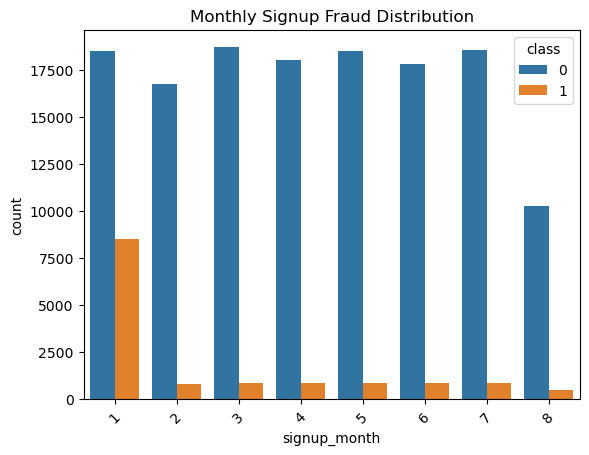

In [83]:
sns.countplot(x='signup_month', hue='class', data=df)
plt.title("Monthly Signup Fraud Distribution")
plt.xticks(rotation=45)
plt.show()

# Insight
First signup month has more fraud

In [84]:
## check purchase month values
df['purchase_month'].value_counts()

purchase_month
7     19507
5     19364
6     18908
8     18662
4     16551
9     14347
3     12090
1     10097
10     9815
2      6449
11     4743
12      579
Name: count, dtype: int64

# insight
 in 2015 year every month(1-12) has signup

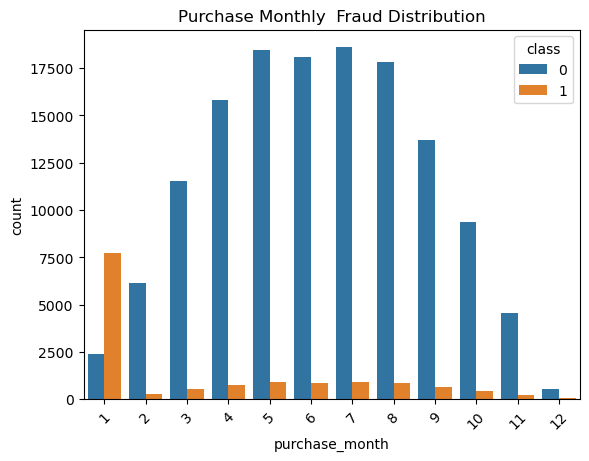

In [85]:
sns.countplot(x='purchase_month', hue='class', data=df)
plt.title("Purchase Monthly  Fraud Distribution")
plt.xticks(rotation=45)
plt.show()

# insight
first month has fraud more

In [86]:
## encoding that columns whose have 2 unique values
df['sex'] = df['sex'].map({'M':0, 'F':1})

In [87]:
# Counts how many times each device_id appears in the dataset
df['device_id_count'] = df.groupby("device_id")["device_id"].transform("count")
# Counts how many times each ip_address appears
df['ip_address_count'] = df.groupby("ip_address")["ip_address"].transform("count")
# Counts unique values per user_id
df["unique_user"] = df.groupby("device_id")["user_id"].transform("nunique")

In [88]:
## drop user_id ,device_id,ip_address columns
df.drop(["user_id","device_id","ip_address"],axis=1,inplace=True)

Preparing X and Y variables

In [89]:
X = df.drop("class",axis=1)
y = df["class"]

<Axes: >

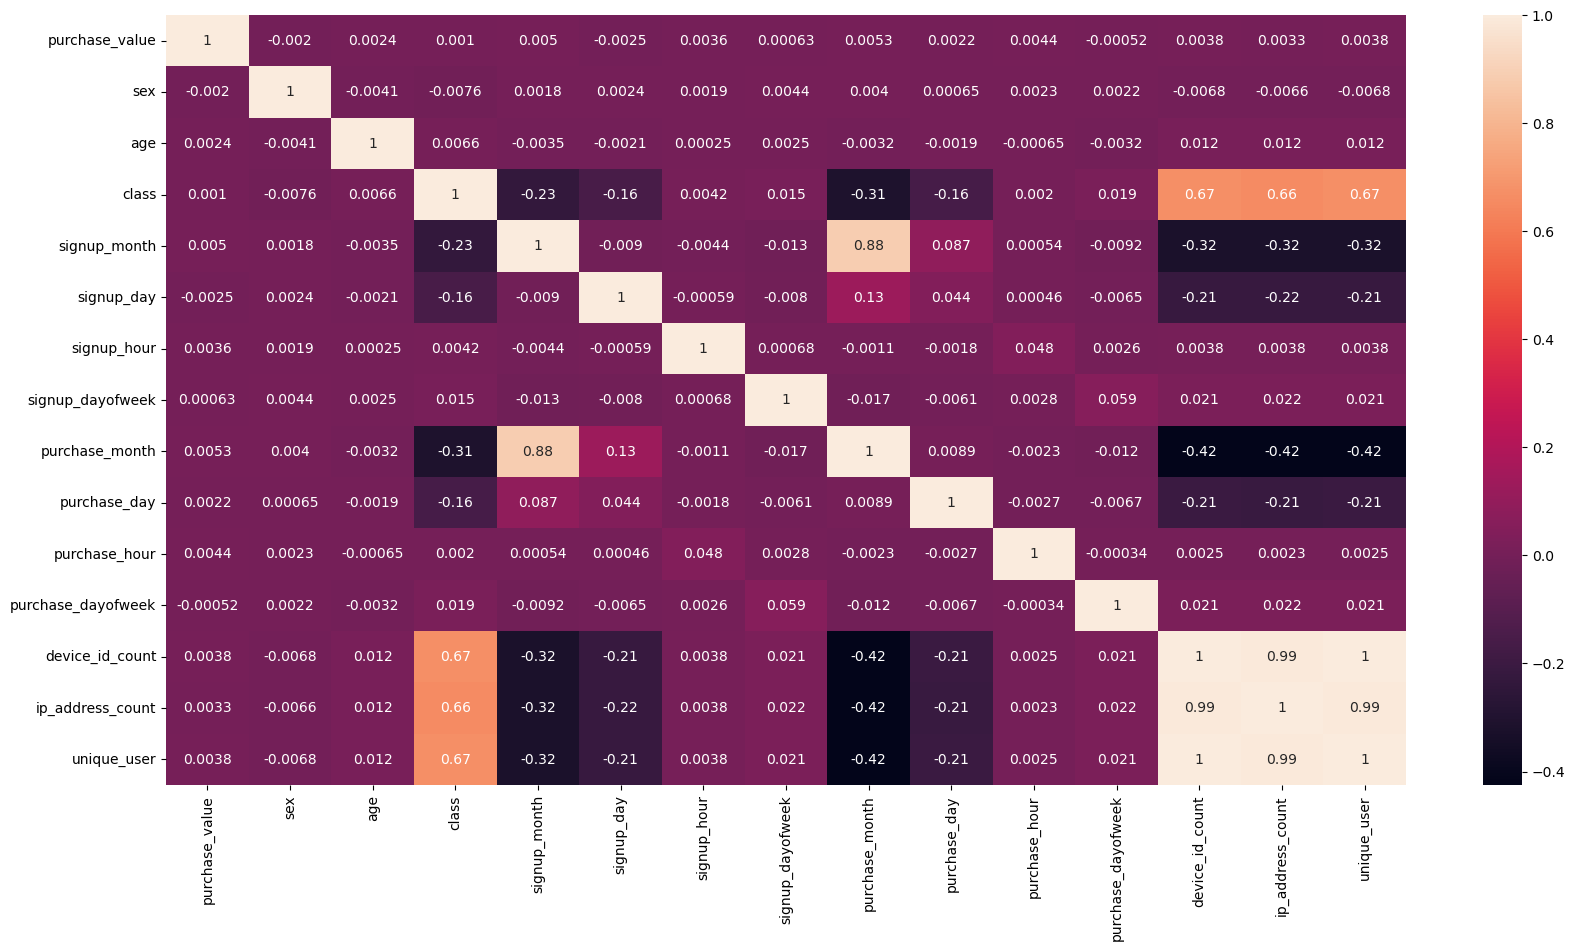

In [90]:
## chekc corr
plt.figure(figsize=(20,10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr,annot=True)

In [91]:
## drop  columns
df.drop(["purchase_hour","purchase_day","signup_dayofweek","signup_day","purchase_value","purchase_value"],axis=1,inplace=True)

In [94]:
num_features = df[['signup_month', 'signup_hour', 'purchase_month', 'purchase_dayofweek', 'device_id_count', 'ip_address_count', 'unique_user',"age"]].columns
from sklearn.preprocessing import  StandardScaler
scaler = StandardScaler()
df[num_features] = scaler.fit_transform(df[num_features])


In [96]:
cat_features = df.select_dtypes(include="object").columns
from sklearn.preprocessing import OneHotEncoder
onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoded_cat = onehot_encoder.fit_transform(df[cat_features])
encoded_cat_df = pd.DataFrame(encoded_cat, columns=onehot_encoder.get_feature_names_out(cat_features))
df = pd.concat([df.drop(cat_features, axis=1), encoded_cat_df], axis=1)

In [98]:
## handle imbalance dataset using SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE()
X,y = smote.fit_resample(df.drop('class', axis=1), df['class'])

In [99]:
##after handling imbalance dataset using SMOTE
y[y==0].shape[0], y[y==1].shape[0]

(136961, 136961)

In [100]:
# separate dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)
X_train.shape, X_test.shape

((191745, 17), (82177, 17))

Create an Evaluate Function to give all metrics after model Training

In [101]:
def evaluate_model(true, predicted):
    Classification_report = classification_report(true,predicted)
    Confusion_matrix = confusion_matrix(true,predicted)
    Accuracy_score = accuracy_score(true,predicted)
    return Classification_report,Confusion_matrix,Accuracy_score

In [102]:
from sympy import true


models = {
    "LogisticRegression" : LogisticRegression(),
    "GaussianNB" : GaussianNB(),
    "BernoulliNB" : BernoulliNB(),
    "KNeighborsClassifier" : KNeighborsClassifier(),
    "DecisionTreeClassifier" : DecisionTreeClassifier(),
    "RandomForestClassifier" : RandomForestClassifier(),
    "AdaBoostClassifier" : AdaBoostClassifier(),
    "XGBClassifier" : XGBClassifier(),
    "CatBoostClassifier" : CatBoostClassifier(),
    "LGBMClassifier": LGBMClassifier(),
    "GradientBoostingClassifier" : GradientBoostingClassifier()
}

model_list = []
accuracy_list = []


for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train,y_train)

    # make prediction
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)  

    # evaluate train and test dataset
    train_classification_report,train_confussion,train_accuracy_score= evaluate_model(y_train,y_train_pred)
    test_classification_report,test_confussion,test_accuracy_score = evaluate_model(y_test,y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print('Model performance for Training set')
    print("Accuracy_Score:", train_accuracy_score)
    print("Confusion_matrix:", train_confussion)
    print("Classification_report:", train_classification_report)


    print('Model performance for Test set')
    print("Accuracy_Score:", test_accuracy_score)
    print("Confusion_matrix:", test_confussion)
    print("Classification_report:", test_classification_report)

    accuracy_list.append(test_accuracy_score)

LogisticRegression
Model performance for Training set
Accuracy_Score: 0.8227228871678531
Confusion_matrix: [[89622  6374]
 [27618 68131]]
Classification_report:               precision    recall  f1-score   support

           0       0.76      0.93      0.84     95996
           1       0.91      0.71      0.80     95749

    accuracy                           0.82    191745
   macro avg       0.84      0.82      0.82    191745
weighted avg       0.84      0.82      0.82    191745

Model performance for Test set
Accuracy_Score: 0.8201078160555874
Confusion_matrix: [[38150  2815]
 [11968 29244]]
Classification_report:               precision    recall  f1-score   support

           0       0.76      0.93      0.84     40965
           1       0.91      0.71      0.80     41212

    accuracy                           0.82     82177
   macro avg       0.84      0.82      0.82     82177
weighted avg       0.84      0.82      0.82     82177

GaussianNB
Model performance for Training set
A

In [103]:
pd.DataFrame(list(zip(model_list, accuracy_list)), columns=['Model Name', 'Accuracy_Score']).sort_values(by=["Accuracy_Score"],ascending=False)

,Model Name,Accuracy_Score
8,CatBoostClassifier,0.975261
9,LGBMClassifier,0.973910
5,RandomForestClassifier,0.971111
7,XGBClassifier,0.969687
4,DecisionTreeClassifier,0.944315
10,GradientBoostingClassifier,0.928240
3,KNeighborsClassifier,0.909281
6,AdaBoostClassifier,0.850068
0,LogisticRegression,0.820108
2,BernoulliNB,0.808182


## Model Selection 
CatBoostClassifier

In [104]:
model= CatBoostClassifier()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
print("Model Accuracy Score:",accuracy_score(y_test,y_pred))

Learning rate set to 0.097198
0:	learn: 0.5841800	total: 21.7ms	remaining: 21.7s
1:	learn: 0.5148220	total: 41.2ms	remaining: 20.6s
2:	learn: 0.4584397	total: 54.8ms	remaining: 18.2s
3:	learn: 0.4207329	total: 67.3ms	remaining: 16.8s
4:	learn: 0.3960856	total: 82.4ms	remaining: 16.4s
5:	learn: 0.3692877	total: 97.2ms	remaining: 16.1s
6:	learn: 0.3511458	total: 111ms	remaining: 15.8s
7:	learn: 0.3383690	total: 125ms	remaining: 15.5s
8:	learn: 0.3259077	total: 138ms	remaining: 15.2s
9:	learn: 0.3166129	total: 155ms	remaining: 15.3s
10:	learn: 0.3073895	total: 169ms	remaining: 15.2s
11:	learn: 0.3028369	total: 183ms	remaining: 15.1s
12:	learn: 0.2924159	total: 199ms	remaining: 15.1s
13:	learn: 0.2823907	total: 215ms	remaining: 15.1s
14:	learn: 0.2714028	total: 230ms	remaining: 15.1s
15:	learn: 0.2666997	total: 245ms	remaining: 15.1s
16:	learn: 0.2604318	total: 260ms	remaining: 15s
17:	learn: 0.2567123	total: 276ms	remaining: 15s
18:	learn: 0.2511422	total: 290ms	remaining: 15s
19:	learn: 

In [105]:
##check model classification reprt
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.98     40965
           1       1.00      0.95      0.97     41212

    accuracy                           0.98     82177
   macro avg       0.98      0.98      0.98     82177
weighted avg       0.98      0.98      0.98     82177



In [106]:
## check model confusion matrix
print(confusion_matrix(y_test,y_pred))

[[40881    84]
 [ 1949 39263]]


In [110]:
##check model feature importance
feature_importance = model.get_feature_importance()
feature_importance_df = pd.DataFrame({"Feature":X.columns,"Importance":feature_importance})
feature_importance_df.sort_values(by="Importance",ascending=False)

,Feature,Importance
3,signup_hour,18.068608
4,purchase_month,16.879224
2,signup_month,14.804345
8,unique_user,14.432248
5,purchase_dayofweek,13.638528
1,age,13.021034
6,device_id_count,7.124289
7,ip_address_count,0.278132
0,sex,0.272452
10,source_Direct,0.271567


In [ ]:
## check model is overfitting or not
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print("Train:", train_acc)
print("Test:", test_acc)

Train: 0.9764739628151973
Test: 0.9752607177190699


In [113]:
# Create a DataFrame showing actual vs predicted marks with error and squared error.
results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
results_df['Error'] = results_df['Actual'] - results_df['Predicted']
results_df['Squared_Error'] = results_df['Error'] ** 2
results_df.head()

,Actual,Predicted,Error,Squared_Error
230571,1,1,0,0
58863,0,0,0,0
83367,0,0,0,0
270121,1,1,0,0
234499,1,1,0,0


In [114]:
results_df.tail()

,Actual,Predicted,Error,Squared_Error
127467,0,0,0,0
148106,0,0,0,0
231954,1,1,0,0
48504,1,0,1,1
8341,0,0,0,0


In [115]:
##sabe model
import pickle

# model save
with open("model.pkl", "wb") as file:
    pickle.dump(model, file)

____